# Fixed Effects Energy Rating
**Author:** Alejandro Orellana

**Date:** Janurary 29, 2026

**Data Source:** Chicago Energy Benchmarking Dataset (2014-2023) - City of Chicago Open Data Portal  

In [1]:
from utils.data_utils import load_data
from utils.plot_utils import plotting_FE_star_coef
from utils.stats_utils import (
    binning_rating,
    prepare_analysis,
    prepared_dataframe,
    run_sensitivity_models,
)

panel_data = prepared_dataframe(load_data())

panel_data["Rating_Bin"] = panel_data["ENERGY STAR Score"].apply(binning_rating)
target_col = "Weather Normalized Site EUI (kBtu/sq ft)"
rating_col = "Rating_Bin"
analysis_df = prepare_analysis(panel_data, target_col, rating_col)
analysis_df.columns

2026-02-01 07:34:29,260 [INFO] ✅ COVID Impact Category assignment (with 'Other' group) complete.
2026-02-01 07:34:29,263 [INFO] Category counts:
COVID Impact Category
Other                    985
Permanent               2370
Stable/Increased       10171
Temporary/Rebounded     5378


----------------------------------------
DATA ANALYSIS PREP SUMMARY
----------------------------------------
Initial Total Rows:        15320
Initial Unique Buildings:  1915
----------------------------------------
Rows with Future Change:   9904
Unique Buildings Retained: 1906
Unique Buildings Lost: 9
----------------------------------------


Index(['Data Year', 'ID', 'Property Name', 'Address', 'ZIP Code',
       'Community Area', 'Primary Property Type',
       'Gross Floor Area - Buildings (sq ft)', 'Year Built', '# of Buildings',
       'ENERGY STAR Score', 'Electricity Use (kBtu)', 'Natural Gas Use (kBtu)',
       'District Steam Use (kBtu)', 'District Chilled Water Use (kBtu)',
       'All Other Fuel Use (kBtu)', 'Site EUI (kBtu/sq ft)',
       'Source EUI (kBtu/sq ft)', 'Weather Normalized Site EUI (kBtu/sq ft)',
       'Weather Normalized Source EUI (kBtu/sq ft)',
       'Total GHG Emissions (Metric Tons CO2e)',
       'GHG Intensity (kg CO2e/sq ft)', 'Latitude', 'Longitude', 'Location',
       'Reporting Status', 'Chicago Energy Rating',
       'Exempt From Chicago Energy Rating', 'Water Use (kGal)', 'Row_ID',
       'COVID Impact Category', 'Effective Year Built', 'Time Built',
       'Rating_Bin', 'Current_EUI', 'Next_Year_EUI', 'Future_Change_Raw',
       'Future_Change', 'Rating_Numeric', 'Rating_Cat', 'Post_Po

In [2]:
analysis_df["Rating_Cat"].value_counts().sort_index()

Rating_Cat
0.0    3421
1.0    2064
1.5    1044
2.0    1291
2.5    1372
3.0    1494
3.5    1682
4.0    2952
Name: count, dtype: int64

## Grouping up the Energy star Ratings

In [3]:
sensitivity_list = run_sensitivity_models(analysis_df)

Status               | Model Name
----------------------------------------
                            OLS Regression Results                            
Dep. Variable:          Future_Change   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     46.62
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           1.84e-65
Time:                        07:34:29   Log-Likelihood:                -40822.
No. Observations:                9904   AIC:                         8.166e+04
Df Residuals:                    9896   BIC:                         8.172e+04
Df Model:                           7                                         
Covariance Type:                  HC1                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
------------------

/project/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 14
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:          Future_Change   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     25.84
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           3.39e-85
Time:                        07:34:30   Log-Likelihood:                -40079.
No. Observations:                9772   AIC:                         8.020e+04
Df Residuals:                    9753   BIC:                         8.033e+04
Df Model:                          18                                         
Covariance Type:                  HC1                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------

/project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 19, but rank is 18
  warnings.warn('covariance of constraints does not have full '


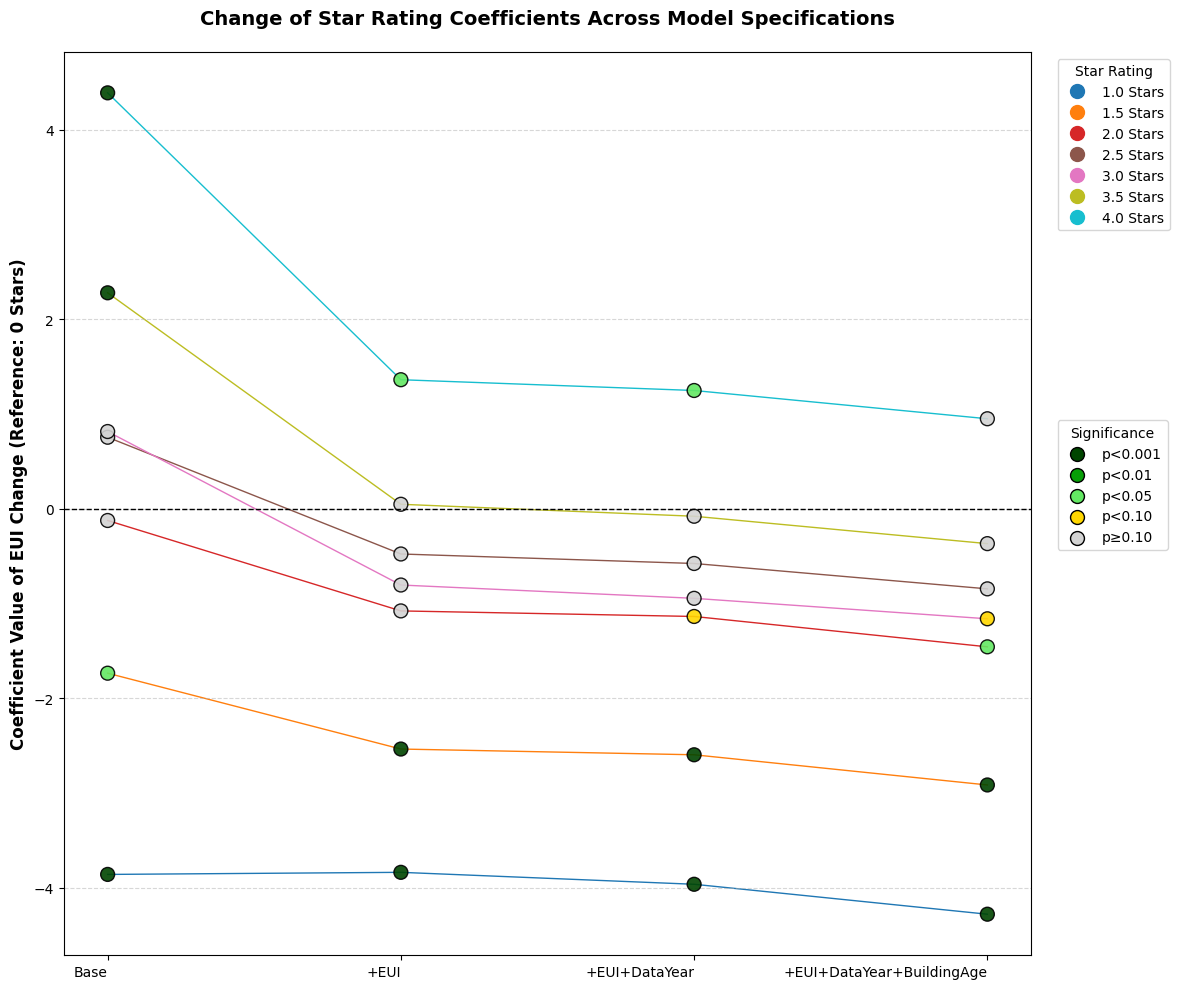

In [4]:
base = (list(sensitivity_list.items())[0][1], "Base")
with_eui = (list(sensitivity_list.items())[1][1], "+EUI")
with_eui_year = (list(sensitivity_list.items())[2][1], "+EUI+DataYear")
with_eui_year_age = (list(sensitivity_list.items())[3][1], "+EUI+DataYear+BuildingAge")

all_formulas = [base, with_eui, with_eui_year, with_eui_year_age]
plot = plotting_FE_star_coef(all_formulas)

The binning of the ENERGY STAR Score was done to reduce the number of coefficients and overfitting. But used it as a opportunity into trying to recreate the Chicago Star score but without the improvement boost it gives. The graph above shows a similar grouping of star scores the the bottom being somewhat close, the middle clumped together, and 4 star on its own. It shows that there may be some categorization of buildings that have been further emphasized by the improvement boost, but the middle group now has statistically insignificant scores so more testing must be done.